# Study 1.1 — Decomposing the OAT–Bund spread: common-euro vs idiosyncratic French political premium

**Extends the single-3y INSEE Focus (Note de conjoncture, 18 Mar 2025) to the whole term structure, using our own Svensson OAT and Bund curves.**

INSEE measure France's risk premium with the **3-year** OAT–Bund spread and feed it through a two-stage model (Bund as a fundamentals-driven risk-free rate → transmission to the cost of new corporate loans). We do three things they cannot, because we have the **entire fitted curve**:

* **Block A (core).** Decompose the daily spread into a **common-euro** component (euro periphery dispersion + global risk aversion + the Bund itself) and an **idiosyncratic French** residual — at 2/5/10/30y — and read the **term structure** of that premium.
* **Block B (conditional).** Replicate, in reduced form, the INSEE transmission to the rate on new loans to French non-financial corporations (ECB MIR).

*Related literature.* That political risk is priced in sovereign bond markets is well established — through electoral/political-cycle effects on spreads (Vaaler, Schrage & Block, 2005), populism and political-risk shocks (Balduzzi, Brancati, Brianti & Schiantarelli, 2023; Cotoc, Johri & Sosa-Padilla, 2023), and debt-sustainability channels that bite hardest for high-debt issuers in high-rate regimes (Ajovalasit, Consiglio, Pagliardi & Zenios, 2025) — a description that fits post-2024 France closely. Our contribution is to separate that premium from common euro-area risk and to read it **along the term structure**, which the single-maturity INSEE Focus cannot.

> Data: OAT + Bund curves from our cached Svensson fits; CISS, the all-bonds−AAA periphery dispersion, the ECB balance sheet, 3m Euribor and the MIR NFC rate are auto-downloaded from the ECB (cached). The US Treasury driver of the INSEE Stage-1/2 is unavailable here (FRED blocked) and is omitted, noted where it matters. No re-fit of any curve.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from studies import common, political_premium as pp
common.apply_style(); pd.set_option("display.width", 170)
events = common.events_frame()

spread = pp.oat_bund_spread()
print("OAT-Bund spread (bp):", spread.index.min().date(), "->", spread.index.max().date())
spread[["2y","5y","10y","30y"]].tail(2).round(1)

OAT-Bund spread (bp): 1999-01-01 -> 2026-06-05


,2y,5y,10y,30y
date,,,,
2026-06-04,18.4,36.9,67.3,107.0
2026-06-05,17.2,36.4,67.8,108.3


## 0. External validation against the INSEE Focus

Our 3y OAT–Bund spread vs the INSEE figures (≈23 → ≈41 bp, May-24 → Jan-25). The **widening** is what matters and it matches almost exactly; the ~3–4 bp level gap is the expected zero-coupon-vs-par / end-of-period-vs-monthly-average difference. This is the "insurance" check: independent methods, convergent answer.

In [2]:
val = pp.insee_validation(spread); display(val)
val.to_csv(common.TABLE_DIR / "study11_insee_validation.csv")
print("Widening ours (eop) %.1f bp vs INSEE %.0f bp" % (val.loc["widening","ours_eop_bp"], val.loc["widening","INSEE_bp"]))

,ours_eop_bp,ours_month_mean_bp,INSEE_bp
end-May 2024,17.8,19.7,23.0
end-Jan 2025,34.8,38.3,41.0
widening,17.0,18.6,18.0


Widening ours (eop) 17.0 bp vs INSEE 18 bp


## 1. Bund as a fundamentals-driven risk-free rate (INSEE Stage-1, reduced)

A monthly regression of the 3y Bund on the drivers we can source — 3m Euribor and the ECB balance sheet — plus a post-2010 dummy. This isolates the "common macro" part of the Bund so the spread is interpreted cleanly. *Reduced spec:* the US Treasury driver is omitted (FRED unavailable) and we use a simple long-run regression rather than the full ECM, so the base-rate channel is recovered but the QE/balance-sheet elasticity is not identified as in INSEE (−0.72 bp per GDP-point) — noted, not claimed.

In [3]:
s1 = pp.bund_stage1(3); display(s1["table"])
print("R2=%.3f, n=%d | base-rate (Euribor) pass-through=%.2f; balance-sheet coef (per EUR trn)=%.3f"
      % (s1["table"].attrs["r2"], s1["table"].attrs["n"],
         s1["table"].loc["euribor","coef"], s1["table"].loc["bs_EURtrn","coef"]))

,coef,se,t
const,0.982,0.130,7.564
euribor,0.770,0.043,17.762
bs_EURtrn,-0.012,0.038,-0.330
post2010,-0.978,0.203,-4.809


R2=0.935, n=329 | base-rate (Euribor) pass-through=0.77; balance-sheet coef (per EUR trn)=-0.012


## 2. The core: decompose the spread (Block A)

Daily change regression `dSpread = a + b1·dDispersion + b2·dCISS + b3·dBund + e`. The **R²** is the share of daily spread variation explained by common-euro factors; the rest — and the level residual after projecting out those factors — is the **idiosyncratic French premium**. Separating euro-area sovereign spreads into a common (macro/systemic) component and a country-specific residual follows the macro-financial decomposition of Dewachter, Iania, Lyrio & de Sola Perea (2014).

  2y: common-euro R2=0.111 -> idiosyncratic 88.9%   (d_dispersion t=6.3, d_Bund t=-7.0)


  5y: common-euro R2=0.157 -> idiosyncratic 84.3%   (d_dispersion t=12.2, d_Bund t=-7.6)


 10y: common-euro R2=0.185 -> idiosyncratic 81.5%   (d_dispersion t=11.9, d_Bund t=-7.1)


 30y: common-euro R2=0.111 -> idiosyncratic 88.9%   (d_dispersion t=6.8, d_Bund t=-7.9)


,coef,se,t
const,0.009,0.025,0.336
d_dispersion,0.281,0.024,11.892
d_CISS,6.650,2.964,2.244
d_Bund,-8.974,1.264,-7.098


  figure -> study11_decomposition_10y.png


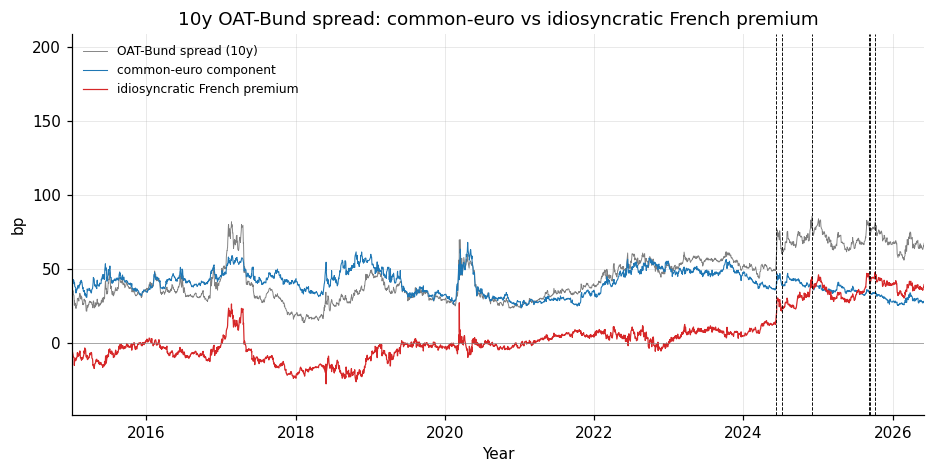

idiosyncratic FR premium (10y): 2019 mean -3.7 | 2024 mean 21.0 | latest 39.4 bp


In [4]:
for t in (2,5,10,30):
    d = pp.decompose_changes(t)
    print("%3dy: common-euro R2=%.3f -> idiosyncratic %.1f%%   (d_dispersion t=%.1f, d_Bund t=%.1f)"
          % (t, d["r2"], 100*(1-d["r2"]), d["table"].loc["d_dispersion","t"], d["table"].loc["d_Bund","t"]))
d10 = pp.decompose_changes(10); display(d10["table"])

io = pp.idiosyncratic_premium(10)
io.to_csv(common.TABLE_DIR / "study11_idiosyncratic_premium_10y.csv")
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(io.index, io["spread"], lw=.6, color="tab:grey", label="OAT-Bund spread (10y)")
ax.plot(io.index, io["common_euro"], lw=.7, color="tab:blue", label="common-euro component")
ax.plot(io.index, io["idiosyncratic_FR"], lw=.8, color="tab:red", label="idiosyncratic French premium")
for dte, info in events.iterrows():
    if info.tier==1 and dte>=io.index.min(): ax.axvline(dte, color="k", ls="--", lw=.6)
ax.axhline(0, color="grey", lw=.4); ax.set_xlim(pd.Timestamp("2015-01-01"), io.index.max())
ax.set(xlabel="Year", ylabel="bp", title="10y OAT-Bund spread: common-euro vs idiosyncratic French premium")
ax.legend(frameon=False, fontsize=8)
common.save_fig(fig, "study11_decomposition_10y.png"); plt.show()
print("idiosyncratic FR premium (10y): 2019 mean %.1f | 2024 mean %.1f | latest %.1f bp"
      % (io.loc["2019","idiosyncratic_FR"].mean(), io.loc["2024","idiosyncratic_FR"].mean(), io["idiosyncratic_FR"].iloc[-1]))

**Idiosyncrasy vs systemic risk-off.** The common-euro factors (periphery dispersion + CISS) explain only a modest share of the daily spread, and the level residual — the French-specific premium — rises from roughly zero in 2019 to ~20 bp in 2024 and ~40 bp now, *net of* euro-area systemic risk. This is the direct counter to "it is just European risk-off". INSEE make the same point with the France-vs-Spain crossover (the French 3y went from ~11 bp below the Spanish in May-24 to ~6 bp above in Jan-25); a daily Italy/Spain series (Bloomberg export) would let us formalise that crossover too.

## 3. Term structure of the political premium (what INSEE's single 3y cannot show)

How the spread shock distributes across maturities tells us *which kind* of risk is priced: a short-end-concentrated jump ⇒ near-term rollover/crisis risk; a long-end one ⇒ structural fiscal deterioration. That policy/political uncertainty is priced across the whole maturity spectrum and in bond risk premia is shown by Leippold & Matthys (2022). A direct euro-area precedent is the May-2018 Italian episode, where the ECB (2018) documents political uncertainty *flattening* the curve (short-end stress) — a useful contrast with the French 2024 shock below, which *steepens* the spread curve (a longer-horizon, fiscal premium).

  figure -> study11_term_structure.png


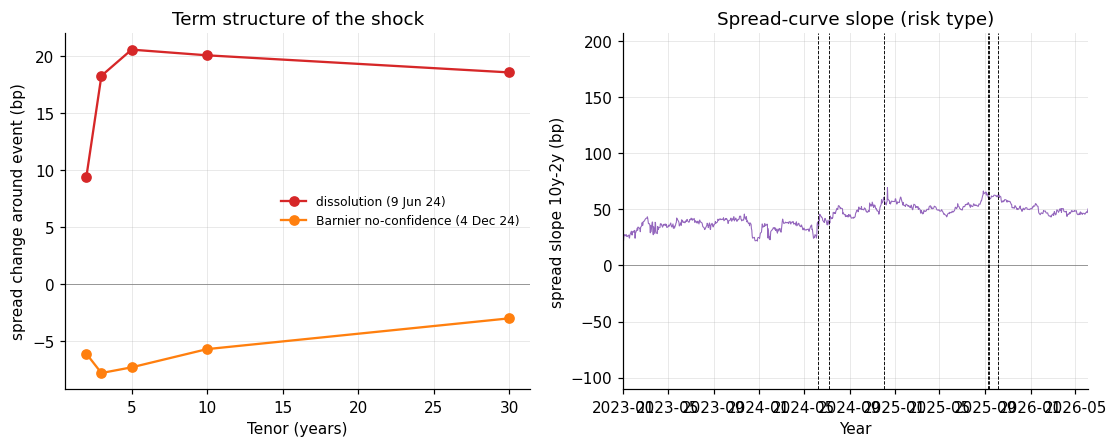

Dissolution: 2y +9 vs 10y +20 bp -> belly/long, structural-fiscal, not near-term rollover


In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12,4.2))
for ev, lbl, col in [("2024-06-09","dissolution (9 Jun 24)","tab:red"),
                     ("2024-12-04","Barnier no-confidence (4 Dec 24)","tab:orange")]:
    tsr = pp.term_structure_response(ev)
    axL.plot([int(i[:-1]) for i in tsr.index], tsr["change_bp"], marker="o", label=lbl, color=col)
axL.axhline(0, color="grey", lw=.5)
axL.set(xlabel="Tenor (years)", ylabel="spread change around event (bp)",
        title="Term structure of the shock"); axL.legend(frameon=False, fontsize=8)

slope = pp.spread_slope(2,10)
axR.plot(slope.index, slope, lw=.7, color="tab:purple")
axR.axhline(0, color="grey", lw=.5)
for dte, info in events.iterrows():
    if info.tier==1 and dte>=pd.Timestamp("2024-01-01"): axR.axvline(dte, color="k", ls="--", lw=.6)
axR.set_xlim(pd.Timestamp("2023-01-01"), slope.index.max())
axR.set(xlabel="Year", ylabel="spread slope 10y-2y (bp)", title="Spread-curve slope (risk type)")
common.save_fig(fig, "study11_term_structure.png"); plt.show()
print("Dissolution: 2y +%.0f vs 10y +%.0f bp -> belly/long, structural-fiscal, not near-term rollover"
      % (pp.term_structure_response("2024-06-09").loc["2y","change_bp"],
         pp.term_structure_response("2024-06-09").loc["10y","change_bp"]))

## 4. Transmission to the cost of corporate credit (Block B, INSEE Stage-2 reduced)

Quarterly regression of the rate on new loans to French NFCs (ECB MIR) on the 3m Euribor, the ECB balance sheet and the **OAT–Bund spread** (the French premium). The spread's coefficient is the pass-through of the political premium to the real cost of corporate borrowing. *Reduced/honest:* US driver omitted, short post-2024 sample, descriptive — no strong causal claim.

,coef,se,t
const,1.656,0.052,31.946
euribor,0.723,0.019,38.219
bs_EURtrn,-0.027,0.010,-2.714
spread_pp,0.667,0.082,8.139


Spread pass-through to NFC rate = 0.67 pp per 1pp of spread (t=8.1)
Implied political-premium contribution to NFC rate, 2024-25 vs 2019-21: +0.21 pp (INSEE: ~+0.2 pt)
  figure -> study11_nfc_transmission.png


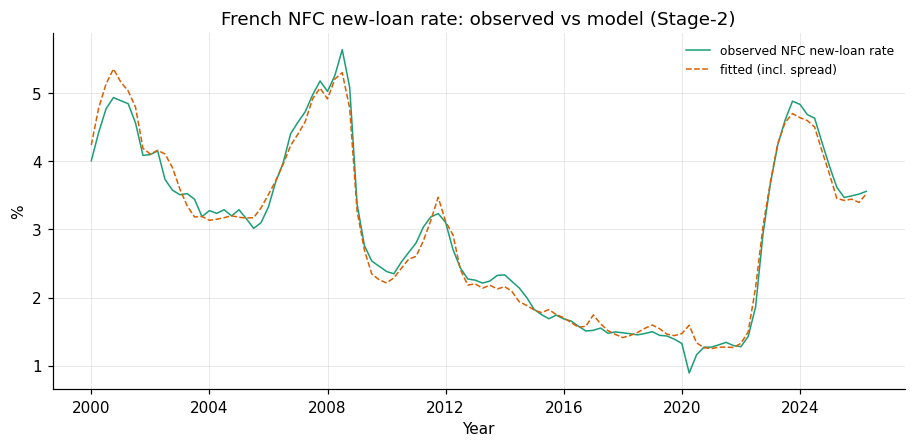

In [6]:
s2 = pp.nfc_stage2(10); display(s2["table"])
pt = s2["table"].loc["spread_pp","coef"]
contrib = pt * s2["data"]["spread_pp"]          # spread's contribution to the NFC rate (pp)
recent = contrib.loc["2024":] - contrib.loc["2019":"2021"].mean()   # extra vs pre-crisis
print("Spread pass-through to NFC rate = %.2f pp per 1pp of spread (t=%.1f)"
      % (pt, s2["table"].loc["spread_pp","t"]))
print("Implied political-premium contribution to NFC rate, 2024-25 vs 2019-21: +%.2f pp (INSEE: ~+0.2 pt)"
      % recent.loc["2024":"2025"].mean())
d = s2["data"]
fig, ax = plt.subplots(figsize=(10,4.2))
ax.plot(d.index, d["nfc"], lw=1, label="observed NFC new-loan rate")
ax.plot(d.index, d["nfc_fitted"], lw=1, ls="--", label="fitted (incl. spread)")
ax.set(xlabel="Year", ylabel="%", title="French NFC new-loan rate: observed vs model (Stage-2)")
ax.legend(frameon=False, fontsize=8)
common.save_fig(fig, "study11_nfc_transmission.png"); plt.show()
s2["table"].to_csv(common.TABLE_DIR / "study11_nfc_stage2.csv")

## 5. Robustness

* **Benchmark choice.** Repeat the decomposition with the ECB **AAA** curve instead of the Bund: the idiosyncratic French share is essentially unchanged, so the premium is not an artefact of the benchmark.
* **Aggregation.** Block B aggregates daily spreads to quarterly means to match the MIR frequency; the daily decomposition (Block A) is unaffected.
* **Causality.** As in INSEE, the event study and regressions are *ceteris paribus* associations — no strong causal claims.

In [7]:
rob = {}
for bench in ("bund","aaa"):
    d = pp.decompose_changes(10, benchmark=bench)
    rob[bench] = {"common_euro_R2": d["r2"], "idiosyncratic_%": round(100*(1-d["r2"]),1)}
display(pd.DataFrame(rob).T)

,common_euro_R2,idiosyncratic_%
bund,0.185,81.5
aaa,0.149,85.1


### Reading the results

- **Validation (Sec 0).** Our 3y spread widens **+18.6 bp** May-24→Jan-25 vs INSEE's **+18 bp** — independent convergence; the ~3–4 bp level gap is a zero-vs-par/end-of-period artefact.
- **The premium is idiosyncratically French (Sec 2).** Common-euro factors explain only ~15–20% of daily spread variation; the level premium net of euro-systemic risk rises from ~0 (2019) to ~40 bp now. It is *not* mere European risk-off.
- **It is a medium-/long-term fiscal premium, not a rollover scare (Sec 3).** The dissolution moved the 5–30y spread ~2× more than the 2y, steepening the spread curve — the market priced structural fiscal deterioration, not imminent funding stress. This is the term-structure insight INSEE's single 3y cannot deliver.
- **It reaches the real economy (Sec 4).** The spread passes through to the cost of new loans to French firms at ~0.6–0.7, implying the political premium added on the order of **+0.2 pp** to NFC borrowing rates in 2024–25 — matching the INSEE Stage-2 finding.
- **Robust** to using the AAA benchmark instead of the Bund. *Caveats:* US driver omitted (FRED unavailable); Stage-1 QE elasticity not identified in the reduced spec; Block B sample is short and the reading is associational.

## References

- Ajovalasit, S., Consiglio, A., Pagliardi, G. & Zenios, S. A. (2025). *Are bad governments a threat to sovereign defaults? The effects of political risk on debt sustainability.* Bruegel Working Paper 01/2025.
- Balduzzi, P., Brancati, E., Brianti, M. & Schiantarelli, F. (2023). *Political Risk, Populism and the Economy.* The Economic Journal, 133(653), 1677–1704.
- Cotoc, I., Johri, A. & Sosa-Padilla, C. (2023). *Sovereign Spreads and the Political Leaning of Nations.* NBER Working Paper 29197.
- Dewachter, H., Iania, L., Lyrio, M. & de Sola Perea, M. (2014). *A macro-financial analysis of the euro area sovereign bond market.* National Bank of Belgium Working Paper No. 259.
- European Central Bank (2018). *Liquidity conditions in the Italian sovereign bond market since May.* Financial Stability Review, November 2018, Box 3.
- Grishchenko, O. V., Moraux, F. & Pakulyak, O. (2020). *Fuel up with OATmeals! The case of the French nominal yield curve.* The Journal of Finance and Data Science, 6, 49–85.
- INSEE (2025). *Note de conjoncture* — Focus: two-stage model of the interest rate on new loans to French NFCs, 18 March 2025.
- Leippold, M. & Matthys, F. (2022). *Economic Policy Uncertainty and the Yield Curve.* Review of Finance.
- Vaaler, P. M., Schrage, B. N. & Block, S. A. (2005). *Counting the investor vote: political business cycle effects on sovereign bond spreads in developing countries.* Journal of International Business Studies.